In [1]:
import os
import sys
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/Users/radinabakalov/TECHTRACK-RADINABAKALOV")
sys.path.append(str(REPO_ROOT))

from techtrack.modules.inference.model import Detector
from techtrack.modules.inference.nms import NMS

In [2]:
# Paths (same layout as the other task notebooks)
DATA_DIR = REPO_ROOT / "techtrack" / "storage" / "logistics"
SAMPLE_LIST = REPO_ROOT / "analysis" / "sample_images.txt"
MODEL2_DIR = REPO_ROOT / "techtrack" / "storage" / "yolo_model_2"
CACHE_DIR = REPO_ROOT / "analysis" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Load the sampled image list we built in Task 2
# (same 6000 images used across all tasks for consistency)
with open(SAMPLE_LIST, "r") as f:
    sample_paths = [Path(line.strip()) for line in f if line.strip()]

print(f"Sample size: {len(sample_paths)} images")

Sample size: 6000 images


In [3]:
# Build Model 2 detector (same config as Task 1)
# Only keep detections the model is at least 50% confident about
SCORE_THRESHOLD = 0.5

# Point to the weights, config, and class names for Model 2
weights = MODEL2_DIR / "yolov4-tiny-logistics_size_416_2.weights"
cfg = MODEL2_DIR / "yolov4-tiny-logistics_size_416_2.cfg"
names = MODEL2_DIR / "logistics.names"

# Load the detector with our confidence threshold
det2 = Detector(str(weights), str(cfg), str(names), score_threshold=SCORE_THRESHOLD)
print("Model 2 loaded.")

Model 2 loaded.


In [4]:
def run_raw_detection(detector, img_path):
    """
    Run the model's forward pass and post-processing, but skip NMS.
    We want the unfiltered detections so we can experiment with different NMS thresholds later without re-running inference.
    """
    # OpenCV needs a string path
    img = cv2.imread(str(img_path))

    # Bail out if the image is corrupt or missing
    if img is None:
        return None

    # Forward pass through the network
    outputs = detector.predict(img)

    # Decode raw outputs into boxes, classes, and scores
    # (but no NMS yet as that's the whole point of this function)
    bboxes, class_ids, scores, cls_scores = detector.post_process(outputs)

    # Package everything up, including image dimensions for later use
    return {
        "bboxes": bboxes,
        "class_ids": class_ids,
        "scores": scores,
        "cls_scores": cls_scores,
        "img_w": img.shape[1],
        "img_h": img.shape[0],
    }

In [5]:
# Where we'll stash the raw (pre-NMS) predictions
RAW_CACHE = CACHE_DIR / "model2_raw_preds.pkl"

if RAW_CACHE.exists():
    # Already ran this before so just load from disk and skip the wait
    with open(RAW_CACHE, "rb") as f:
        raw_preds = pickle.load(f)
    print(f"Loaded {len(raw_preds)} cached raw predictions.")
else:
    # No cache yet (run inference on every sample image)
    # (this takes a few minutes, so we cache it afterwards)
    raw_preds = []
    for i, img_path in enumerate(sample_paths, 1):
        raw = run_raw_detection(det2, img_path)
        raw_preds.append({"img_path": str(img_path), "raw": raw})

        # Progress update every 500 images so we know it's alive
        if i % 500 == 0:
            print(f"Progress: {i}/{len(sample_paths)}")

    # Save so we never have to do this again
    with open(RAW_CACHE, "wb") as f:
        pickle.dump(raw_preds, f)
    print(f"Cached {len(raw_preds)} raw predictions to {RAW_CACHE}")

Loaded 6000 cached raw predictions.


In [6]:
def get_label_path(img_path: Path):
    """Swap .jpg to .txt to find the matching YOLO label file."""
    return Path(img_path).with_suffix(".txt")


def yolo_txt_to_boxes(txt_path: Path, img_w: int, img_h: int):
    """
    Parse a YOLO .txt label file into pixel-space bounding boxes.
    Returns (gt_boxes, gt_classes) where boxes are [x, y, w, h] in pixels.
    """
    # If there's no label file, this image has no annotations
    if not txt_path.exists():
        return [], []

    gt_boxes = []
    gt_classes = []

    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            # Each valid YOLO line has exactly 5 values (class cx cy w h)
            if len(parts) != 5:
                continue

            cls = int(float(parts[0]))
            # YOLO stores coordinates as normalized center-x, center-y, width, height
            cx, cy, w, h = map(float, parts[1:])

            # Convert from normalized center format to pixel corner format
            # (top-left x, top-left y, box width, box height)
            bw = int(round(w * img_w))
            bh = int(round(h * img_h))
            x = int(round((cx * img_w) - bw / 2))
            y = int(round((cy * img_h) - bh / 2))

            gt_boxes.append([x, y, bw, bh])
            gt_classes.append(cls)

    return gt_boxes, gt_classes

In [7]:
def iou_xywh(a, b):
    """Compute Intersection over Union for two boxes in [x, y, w, h] format."""
    # Unpack both boxes
    ax, ay, aw, ah = a
    bx, by, bw, bh = b

    # Get the bottom-right corners of each box
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    # Find the overlap rectangle (if any)
    ix1 = max(ax, bx)
    iy1 = max(ay, by)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # To zero (if the boxes don't overlap, the width/height will be negative)
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Union = both areas combined, minus the overlap we counted twice
    union = max(0, aw) * max(0, ah) + max(0, bw) * max(0, bh) - inter
    
    # Avoid division by zero if something slipped in
    return (inter / union) if union > 0 else 0.0

In [8]:
def eval_predictions(preds, iou_thr=0.5, num_classes=20):
    """
    Evaluate predictions against ground truth using greedy IoU matching.
    Returns a DataFrame with per-class precision, recall, and F1.
    """
    # Per-class counters for the confusion breakdown
    tp = np.zeros(num_classes, dtype=int) # correctly detected
    fp = np.zeros(num_classes, dtype=int) # predicted but wrong
    fn = np.zeros(num_classes, dtype=int) # missed entirely

    for row in preds:
        img_path = Path(row["img_path"])
        pred = row["pred"]

        # We need the image dimensions to convert YOLO labels to pixel coords
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img_h, img_w = img.shape[:2]
        gt_boxes, gt_classes = yolo_txt_to_boxes(
            get_label_path(img_path), img_w, img_h
        )

        # If the detector returned nothing, every ground truth box is a miss
        if pred is None:
            for c in gt_classes:
                fn[c] += 1
            continue

        pred_boxes = pred["bboxes"]
        pred_classes = pred["class_ids"]

        # Track which ground truth boxes have already been claimed
        matched_gt = [False] * len(gt_boxes)

        # Greedy matching
        # For each predicted box, find the best-overlapping GT box of the same class that hasn't been matched yet
        for pb, pc in zip(pred_boxes, pred_classes):
            best_iou, best_j = 0.0, -1

            for j, (gb, gc) in enumerate(zip(gt_boxes, gt_classes)):
                # Skip GTs that are already taken or a different class
                if matched_gt[j] or gc != pc:
                    continue
                cur_iou = iou_xywh(pb, gb)
                if cur_iou > best_iou:
                    best_iou = cur_iou
                    best_j = j

            # Good enough overlap? Count it as a hit
            if best_iou >= iou_thr and best_j != -1:
                tp[pc] += 1
                matched_gt[best_j] = True
            else:
                # Either no match or IoU too low, then it's a false positive
                fp[pc] += 1

        # Any GT box that nobody claimed is a false negative
        for j, gc in enumerate(gt_classes):
            if not matched_gt[j]:
                fn[gc] += 1

    # Compute metrics from the raw counts
    # np.maximum avoids division by zero for classes with no predictions/labels
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = (2 * precision * recall) / np.maximum(precision + recall, 1e-9)

    return pd.DataFrame({
        "class_id": np.arange(num_classes),
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "f1": f1,
    })

In [9]:
def apply_nms_and_evaluate(raw_preds, nms_iou_thresh, score_thresh=0.5):
    """
    Take raw (pre-NMS) detections, apply NMS at a given threshold, and return the evaluation DataFrame. 
    This lets us test different NMS settings without re-running the expensive inference step.
    """
    # Build a fresh NMS instance with the threshold we want to test
    nms = NMS(score_threshold=score_thresh, nms_iou_threshold=nms_iou_thresh)

    filtered_preds = []
    for row in raw_preds:
        raw = row["raw"]

        # If the image failed to load during inference, pass it through as-is
        if raw is None:
            filtered_preds.append({"img_path": row["img_path"], "pred": None})
            continue

        # Apply NMS with the current threshold to filter overlapping boxes
        bboxes, class_ids, scores, cls_scores = nms.filter(
            raw["bboxes"], raw["class_ids"],
            raw["scores"], raw["cls_scores"],
        )

        # Pack back into the format that eval_predictions expects
        # If NMS removed everything, treat it as no detections
        pred = {
            "bboxes": bboxes,
            "class_ids": class_ids,
            "scores": scores,
            "cls_scores": cls_scores,
            "img_w": raw["img_w"],
            "img_h": raw["img_h"],
        } if bboxes else None

        filtered_preds.append({"img_path": row["img_path"], "pred": pred})
        
    # Run the same evaluation logic from Task 1 on the filtered predictions
    return eval_predictions(filtered_preds)

In [10]:
# The thresholds we want to test
# Low threshold = aggressive suppression (fewer boxes kept)
# High threshold = permissive (more overlapping boxes survive)
nms_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

sweep_results = []

for nms_thresh in nms_thresholds:
    # Evaluate with this NMS threshold
    df = apply_nms_and_evaluate(raw_preds, nms_thresh)

    # Macro-average across all classes (treats every class equally)
    macro_prec = df["precision"].mean()
    macro_rec = df["recall"].mean()
    macro_f1 = df["f1"].mean()

    # Also grab the total raw counts for context
    total_tp = df["tp"].sum()
    total_fp = df["fp"].sum()
    total_fn = df["fn"].sum()

    # Store this threshold's results
    sweep_results.append({
        "nms_threshold": nms_thresh,
        "precision": macro_prec,
        "recall": macro_rec,
        "f1": macro_f1,
        "total_tp": total_tp,
        "total_fp": total_fp,
        "total_fn": total_fn,
    })

    # Print so we can watch the tradeoff as we go
    print(f"NMS={nms_thresh:.1f}  |  P={macro_prec:.4f}  R={macro_rec:.4f}  F1={macro_f1:.4f}  |  TP={total_tp}  FP={total_fp}  FN={total_fn}")

# Collect everything into a DataFrame for easy comparison
sweep_df = pd.DataFrame(sweep_results)
sweep_df

NMS=0.1  |  P=0.8307  R=0.4967  F1=0.5974  |  TP=9757  FP=2366  FN=13830
NMS=0.2  |  P=0.8259  R=0.5072  F1=0.6047  |  TP=10195  FP=2542  FN=13392
NMS=0.3  |  P=0.8251  R=0.5151  F1=0.6113  |  TP=10436  FP=2612  FN=13151
NMS=0.4  |  P=0.8238  R=0.5219  F1=0.6169  |  TP=10606  FP=2675  FN=12981
NMS=0.5  |  P=0.8204  R=0.5267  F1=0.6194  |  TP=10729  FP=2779  FN=12858
NMS=0.6  |  P=0.8028  R=0.5294  F1=0.6157  |  TP=10828  FP=3008  FN=12759
NMS=0.7  |  P=0.7565  R=0.5327  F1=0.6007  |  TP=10903  FP=3721  FN=12684
NMS=0.8  |  P=0.6487  R=0.5354  F1=0.5552  |  TP=10975  FP=6008  FN=12612
NMS=0.9  |  P=0.5141  R=0.5378  F1=0.4836  |  TP=11017  FP=10899  FN=12570


,nms_threshold,precision,recall,f1,total_tp,total_fp,total_fn
0,0.1,0.830713,0.496691,0.597388,9757,2366,13830
1,0.2,0.825941,0.507248,0.604705,10195,2542,13392
2,0.3,0.825090,0.515104,0.611319,10436,2612,13151
3,0.4,0.823768,0.521943,0.616874,10606,2675,12981
4,0.5,0.820415,0.526665,0.619356,10729,2779,12858
5,0.6,0.802756,0.529391,0.615738,10828,3008,12759
6,0.7,0.756521,0.532686,0.600736,10903,3721,12684
7,0.8,0.648705,0.535372,0.555226,10975,6008,12612
8,0.9,0.514084,0.537762,0.483564,11017,10899,12570


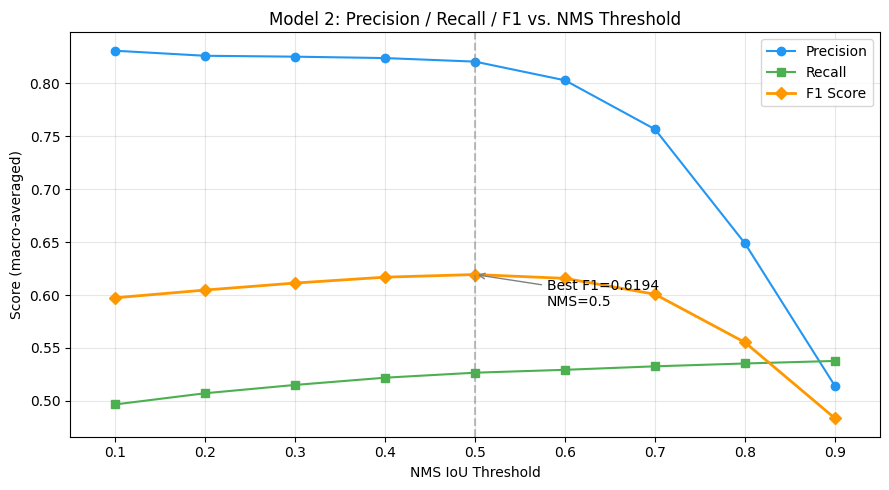


Best NMS threshold by macro F1: 0.5


In [11]:
# Make sure the figures folder exists before we try to save anything
(REPO_ROOT / "analysis" / "figures").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))

# Plot all three metrics so we can see the trade-off clearly
# As NMS gets more permissive, recall goes up but precision drops
ax.plot(sweep_df["nms_threshold"], sweep_df["precision"], "o-", label="Precision", color="#2196F3")
ax.plot(sweep_df["nms_threshold"], sweep_df["recall"], "s-", label="Recall", color="#4CAF50")
ax.plot(sweep_df["nms_threshold"], sweep_df["f1"], "D-", label="F1 Score", color="#FF9800", linewidth=2)

# Mark the best F1 point
best_idx = sweep_df["f1"].idxmax()
best_thresh = sweep_df.loc[best_idx, "nms_threshold"]
best_f1 = sweep_df.loc[best_idx, "f1"]

# Draw a vertical dashed line at the best threshold
ax.axvline(best_thresh, color="gray", linestyle="--", alpha=0.5)

# Add an annotation arrow pointing to the peak
ax.annotate(
    f"Best F1={best_f1:.4f}\nNMS={best_thresh}",
    xy=(best_thresh, best_f1),
    xytext=(best_thresh + 0.08, best_f1 - 0.03),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="gray"),
)

ax.set_xlabel("NMS IoU Threshold")
ax.set_ylabel("Score (macro-averaged)")
ax.set_title("Model 2: Precision / Recall / F1 vs. NMS Threshold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0.05, 0.95)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / "analysis" / "figures" / "nms_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest NMS threshold by macro F1: {best_thresh}")

In [12]:
# Evaluate at the best threshold we just found, and at the original default (0.4) so we can see what actually changed
df_best = apply_nms_and_evaluate(raw_preds, best_thresh)
df_default = apply_nms_and_evaluate(raw_preds, 0.4)

# Merge them side by side so we can see the delta per class
compare = df_best.merge(df_default, on="class_id", suffixes=("_best", "_default"))
compare["f1_delta"] = compare["f1_best"] - compare["f1_default"]

# Sort by biggest improvement first
compare = compare.sort_values("f1_delta", ascending=False)

print(f"Per-class comparison: NMS={best_thresh} vs NMS=0.4")
compare[["class_id", "precision_best", "recall_best", "f1_best",
         "precision_default", "recall_default", "f1_default", "f1_delta"]]

Per-class comparison: NMS=0.5 vs NMS=0.4


,class_id,precision_best,recall_best,f1_best,precision_default,recall_default,f1_default,f1_delta
13,13,0.887379,0.544048,0.674539,0.896930,0.486905,0.631173,0.043366
10,10,0.823892,0.498015,0.620786,0.829680,0.488337,0.614808,0.005978
8,8,0.767442,0.356757,0.487085,0.773810,0.351351,0.483271,0.003813
4,4,0.901487,0.726048,0.804312,0.903955,0.718563,0.800667,0.003645
7,7,0.736946,0.531250,0.617416,0.737575,0.526989,0.614747,0.002669
19,19,0.569462,0.218785,0.316119,0.572396,0.216701,0.314382,0.001737
3,3,0.830508,0.133225,0.229616,0.829932,0.132681,0.228786,0.000830
1,1,0.878536,0.636912,0.738462,0.879800,0.635706,0.738095,0.000366
16,16,0.903481,0.750329,0.819813,0.904762,0.749014,0.819554,0.000259
6,6,0.944954,0.628049,0.754579,0.944954,0.628049,0.754579,0.000000


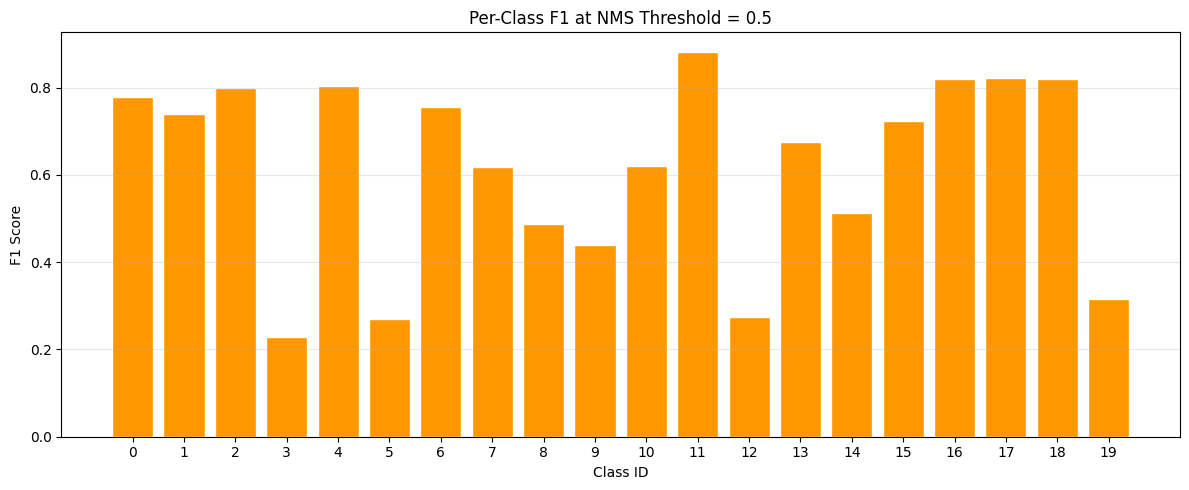

In [13]:
# Bar chart showing how each class performs at the optimal NMS threshold
fig, ax = plt.subplots(figsize=(12, 5))

# Sort by class id so the bars line up nicely
df_plot = df_best.sort_values("class_id")
ax.bar(df_plot["class_id"], df_plot["f1"], color="#FF9800", edgecolor="white")

ax.set_xlabel("Class ID")
ax.set_ylabel("F1 Score")
ax.set_title(f"Per-Class F1 at NMS Threshold = {best_thresh}")
ax.set_xticks(range(20))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / "analysis" / "figures" / "nms_best_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()

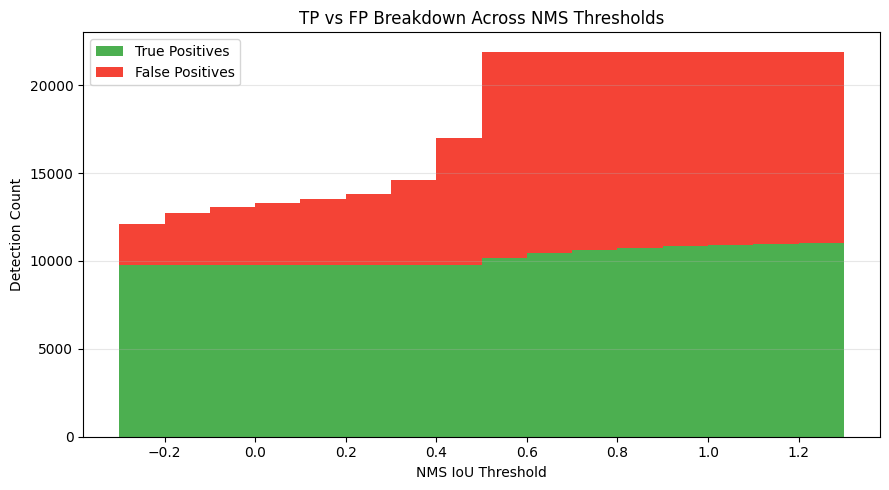

In [14]:
# Stacked bar chart showing how the TP/FP balance shifts as we make NMS more or less aggressive
fig, ax = plt.subplots(figsize=(9, 5))

# Green bars = true positives (good detections)
ax.bar(sweep_df["nms_threshold"], sweep_df["total_tp"], label="True Positives", color="#4CAF50")

# Red bars stacked on top = false positives (ghost detections)
ax.bar(sweep_df["nms_threshold"], sweep_df["total_fp"],
       bottom=sweep_df["total_tp"], label="False Positives", color="#F44336")

ax.set_xlabel("NMS IoU Threshold")
ax.set_ylabel("Detection Count")
ax.set_title("TP vs FP Breakdown Across NMS Thresholds")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPO_ROOT / "analysis" / "figures" / "nms_detection_counts.png"), dpi=150, bbox_inches="tight")
plt.show()

In [15]:
import random
from collections import Counter

def analyze_errors_at_threshold(raw_preds, nms_iou_thresh, score_thresh=0.5, max_examples=50):
    """
    Apply NMS at a specific threshold and collect false positive / false negative examples. 
    Useful for understanding what kinds of mistakes remain after tuning.
    Are we still hallucinating boxes, or missing real objects?
    """
    # Build an NMS instance with the threshold we want to inspect
    nms = NMS(score_threshold=score_thresh, nms_iou_threshold=nms_iou_thresh)

    false_positives = [] # model "saw" something that isn't there
    false_negatives = [] # model missed a real object

    for row in raw_preds:
        img_path = Path(row["img_path"])
        raw = row["raw"]

        # Need the actual image to get its dimensions for label conversion
        img = cv2.imread(str(img_path))

        # If we can't load the image or inference failed earlier, skip it
        if img is None or raw is None:
            continue

        img_h, img_w = img.shape[:2]
        gt_boxes, gt_classes = yolo_txt_to_boxes(
            get_label_path(img_path), img_w, img_h
        )

        # Apply NMS at our chosen threshold
        bboxes, class_ids, scores, cls_scores = nms.filter(
            raw["bboxes"], raw["class_ids"],
            raw["scores"], raw["cls_scores"],
        )

        # If NMS wiped everything out, every GT object counts as missed
        if not bboxes:
            for c in gt_classes:
                false_negatives.append((str(img_path), c))
            continue
        
        # Track which GT boxes get successfully matched
        matched_gt = [False] * len(gt_boxes)

        # Greedy matching (same logic as eval_predictions)
        # Try to pair each predicted box with the best overlapping GT
        for pb, pc in zip(bboxes, class_ids):
            best_iou, best_j = 0.0, -1
            for j, (gb, gc) in enumerate(zip(gt_boxes, gt_classes)):
                # Skip already claimed GTs or wrong class GTs
                if matched_gt[j] or gc != pc:
                    continue
                cur = iou_xywh(pb, gb)
                if cur > best_iou:
                    best_iou = cur
                    best_j = j

            if best_iou >= 0.5 and best_j != -1:
                # Good match (this prediction found its partner)
                matched_gt[best_j] = True
            else:
                # No good match (this is a ghost detection)
                false_positives.append((str(img_path), pc))

        # Any GT box that nobody claimed is a miss
        for j, gc in enumerate(gt_classes):
            if not matched_gt[j]:
                false_negatives.append((str(img_path), gc))

        # Once we have enough examples of both error types, stop early
        # (we just need a representative sample for qualitative analysis)
        if len(false_positives) > max_examples and len(false_negatives) > max_examples:
            break

    return false_positives, false_negatives

In [16]:
# Collect error examples using the best NMS threshold we found
fps, fns = analyze_errors_at_threshold(raw_preds, best_thresh)

print(f"Sampled errors at NMS={best_thresh}:")
print(f"  False positives: {len(fps)}")
print(f"  False negatives: {len(fns)}")

# Which classes cause the most trouble?
fp_by_class = Counter([cls for _, cls in fps])
fn_by_class = Counter([cls for _, cls in fns])

print(f"\nTop FP classes: {fp_by_class.most_common(5)}")
print(f"Top FN classes: {fn_by_class.most_common(5)}")

Sampled errors at NMS=0.5:
  False positives: 52
  False negatives: 236

Top FP classes: [(19, 17), (10, 11), (17, 4), (15, 4), (5, 3)]
Top FN classes: [(19, 101), (3, 33), (10, 27), (7, 14), (2, 8)]


False Positive Examples


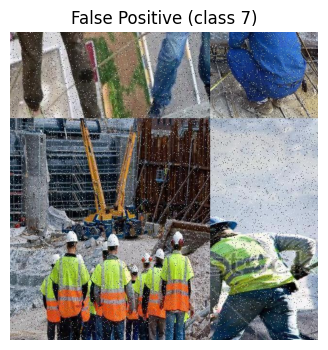

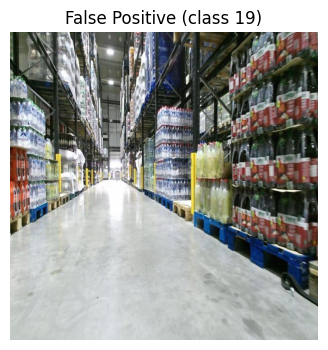

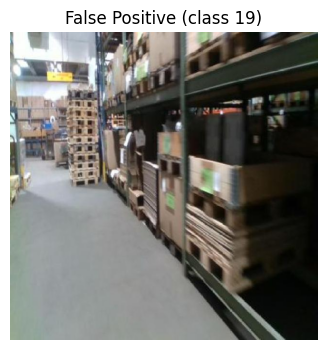


False Negative Examples


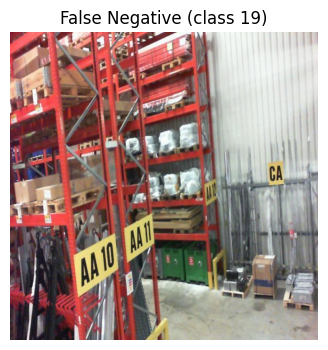

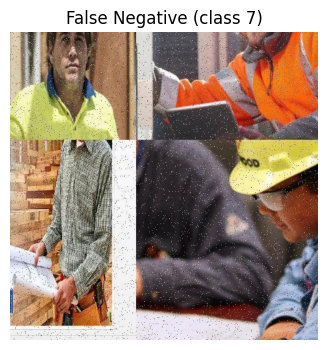

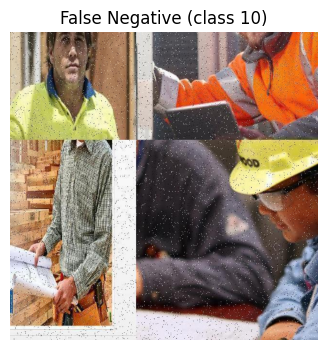

In [17]:
def show_image(img_path, title=""):
    """Helper to display a single image with a title."""
    # OpenCV loads as BGR, matplotlib expects RGB
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Visualize some error cases at the optimized NMS threshold
# Randomly sample a few of each so we get a varied look

# Show a few false positives (ghost detections the model hallucinated)
print("False Positive Examples")
for img_path, cls in random.sample(fps, min(3, len(fps))):
    show_image(img_path, title=f"False Positive (class {cls})")

# Show a few false negatives (real objects the model missed)
print("\nFalse Negative Examples")
for img_path, cls in random.sample(fns, min(3, len(fns))):
    show_image(img_path, title=f"False Negative (class {cls})")